## Model Loading

In [68]:
import torch
from pathlib import Path
import sys

# 루트 경로 추가 (Model, dataset 로딩 위해)
root_dir = Path('/home/eungyeop/LLM/tabular/ProtoLLM_entropic20251217')
sys.path.append(str(root_dir))

from models.TabularFLM_S_ import Model
from dataset.data_dataloaders import prepare_embedding_dataloaders
from utils.util import fix_seed
from ot.batch import solve_gromov_batch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1.0_alpha-0.5_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-EXP3_REG_ALPHA05_FGW1/50/20260318_140439/best_joint.pt"
ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records_till_20260317/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-XTFORMER_EVALUATION100/50/20260225_221853/best_joint.pt"
target_rr_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records_till_20260317/Few/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-XTFORMER_EVALUATION100/50/20260225_221853/Embed:carte_Edge:mlp_A:gat_v1_S:50_20260225_221853.pt"
ckpt = torch.load(ckpt_path, map_location=device)
args = ckpt['args']

model = Model(
    args,
    args.input_dim,
    args.hidden_dim,
    args.output_dim,
    args.dropout_rate,
    args.llm_model,
    experiment_id="viz",
    mode="viz"
).to(device)

sd = ckpt['model_state_dict']
missing, unexpected = model.load_state_dict(sd, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()

Missing keys: []
Unexpected keys: []


Model(
  (latent_graph): LatentCompositeGraph()
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x ModuleList(
        (0-1): 2 x lightGraphNeuralNet(
          (dropout): Dropout(p=0.1, inplace=False)
          (linear): Linear(in_features=768, out_features=192, bias=True)
          (update): Linear(in_features=192, out_features=768, bias=True)
          (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (attn): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): Tanh()
          (2): Linear(in_features=192, out_features=1, bias=True)
        )
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
 

## Source Loading

In [69]:
args2 = args
fix_seed(args2.random_seed)

sources = args2.source_data if isinstance(args2.source_data, (list, tuple)) else [args2.source_data]

loaders = {}
for src in sources:
    print(f"Loading dataloader for source: {src}")
    res = prepare_embedding_dataloaders(args2, src, is_source=True)
    tr, va, te = res['loaders']

    from torch.utils.data import ConcatDataset, DataLoader
    datasets = [l.dataset for l in [tr, va, te] if l is not None]
    ds = ConcatDataset(datasets)

    loaders[src] = DataLoader(ds, batch_size=32, shuffle=False)

>>> [System] Seed 50 FIXED. Deterministic algorithms ENABLED.
Loading dataloader for source: Medicaldataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Medicaldataset.pkl
>>> [DataLoader] Created isolated generator with seed 50
[Source] Training data size: 1121
[Source] Validation data size: 198
Loading dataloader for source: Cardiovascular_Disease_Dataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Cardiovascular_Disease_Dataset.pkl
>>> [DataLoader] Created isolated generator with seed 50
[Source] Training data size: 850
[Source] Validation data size: 150
Loading dataloader for source: Heart_disease_statlog
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Heart_disease_statlog.pkl
>>> [DataLoader] Created isolated generator with seed 50
[Source] Training data size: 229
[Source] Va

## Helpers: load tabular, one-hot basis risk, TP/TN extraction

In [70]:
import numpy as np
import pandas as pd
import torch.nn.functional as F

base_table_path = "/storage/personal/eungyeop/dataset/table/origin_table"

dataset_and_class = {
    "heart": ['target_binary', ['no','yes']],
    "Cardiovascular_Disease_Dataset": ['target_binary', ['no', 'yes']],
    "Medicaldataset": ['target_binary', ['no', 'yes']],
    "Heart_disease_statlog": ['target_binary', ['no','yes']],
    "Erbil_Cardiovascular_Health_Dataset": ['target_binary', ['no','yes']],
    "cardio_SAheart": ['target_binary', ['no','yes']],
    "heart_failure_clinical_records": ['target_binary', ['no','yes']],
}

label_col_map = {
    "Cardiovascular_Disease_Dataset": "target",
    "Medicaldataset": "Result",
    "heart1": "output",
}

def load_original_tabular(dataset_name):
    csv_path = f"{base_table_path}/{dataset_name}.csv"
    df = pd.read_csv(csv_path)
    class_info = dataset_and_class.get(dataset_name)
    if class_info is None:
        for col in ['target_binary', 'target', 'Result', 'output', 'target_multiclass']:
            if col in df.columns:
                y = df[col]; X = df.drop(col, axis=1)
                return X.reset_index(drop=True), y.reset_index(drop=True)
        raise ValueError(f"Cannot find label column for {dataset_name}")
    class_name = class_info[0]
    if dataset_name in label_col_map:
        orig_col = label_col_map[dataset_name]
        if orig_col in df.columns:
            df[class_name] = df[orig_col]; df = df.drop(orig_col, axis=1)
    if class_name in df.columns:
        X = df.drop(class_name, axis=1); y = df[class_name]
    else:
        raise ValueError(f"Label column '{class_name}' not found")
    return X.reset_index(drop=True), y.reset_index(drop=True)


@torch.no_grad()
def compute_onehot_basis_risk(model, device):
    model.eval()
    lcg_feat, lcg_struct = model.latent_graph()
    M = lcg_feat.shape[0]
    expert_outputs = model.gnn_experts(lcg_feat.unsqueeze(0), lcg_struct.unsqueeze(0))

    onehot_probs = []
    for k in range(M):
        pi_onehot = torch.zeros(1, M, device=device)
        pi_onehot[0, k] = 1.0
        weighted = (pi_onehot.unsqueeze(-1) * expert_outputs).sum(dim=1)
        current_mode = getattr(model, 'mode', 'Full')
        logit = model.ghead2(weighted) if current_mode == 'Few' else model.ghead(weighted)
        onehot_probs.append(torch.sigmoid(logit).item())

    print("One-Hot Basis Risk:")
    for k in range(M):
        label = "HIGH" if onehot_probs[k] > 0.5 else "LOW"
        print(f"  B{k}: {onehot_probs[k]:.4f} → {label}")
    return np.array(onehot_probs)


@torch.no_grad()
def extract_tp_tn_with_tabular(model, loader, device, dataset_name):
    model.eval()
    X_orig, y_orig = load_original_tabular(dataset_name)
    all_pi, all_y, all_prob, all_sidx = [], [], [], []

    for batch in loader:
        batch_t = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        out = model.predict(batch_t, return_all=True)
        global_pred = out[0] if isinstance(out, tuple) else out
        pi = model.graph_quantizer.last_pi
        prob = torch.sigmoid(global_pred).squeeze(-1)
        all_pi.append(pi.cpu().numpy())
        all_y.append(batch_t['y'].cpu().view(-1).numpy())
        all_prob.append(prob.cpu().view(-1).numpy())
        if 's_idx' in batch_t:
            sidx = batch_t['s_idx']
            if isinstance(sidx, torch.Tensor): all_sidx.append(sidx.cpu().view(-1).numpy())
            else: all_sidx.append(np.array([sidx] * pi.shape[0]))
        else:
            start = sum(len(s) for s in all_sidx)
            all_sidx.append(np.arange(start, start + pi.shape[0]))

    pis = np.concatenate(all_pi); ys = np.concatenate(all_y).astype(int)
    probs = np.concatenate(all_prob); sidxs = np.concatenate(all_sidx).astype(int)
    preds = (probs >= 0.5).astype(int)
    valid = sidxs < len(X_orig)
    if not valid.all():
        pis, ys, probs, sidxs, preds = pis[valid], ys[valid], probs[valid], sidxs[valid], preds[valid]

    tp = (ys == 1) & (preds == 1); tn = (ys == 0) & (preds == 0)
    fp = (ys == 0) & (preds == 1); fn = (ys == 1) & (preds == 0)
    X_mapped = X_orig.iloc[sidxs].reset_index(drop=True)

    print(f"[{dataset_name}] N={len(ys)}, TP={tp.sum()}, TN={tn.sum()}, FP={fp.sum()}, FN={fn.sum()}")
    return {'dataset_name': dataset_name, 'X': X_mapped, 'pis': pis, 'ys': ys,
            'probs': probs, 'preds': preds, 'argmax': pis.argmax(axis=1),
            'tp_mask': tp, 'tn_mask': tn, 'fp_mask': fp, 'fn_mask': fn}

## Build `onehot_probs` and `all_results`

In [71]:
onehot_probs = compute_onehot_basis_risk(model, device)

all_results = {}
for src_name in sources:
    all_results[src_name] = extract_tp_tn_with_tabular(model, loaders[src_name], device, src_name)

One-Hot Basis Risk:
  B0: 0.0240 → LOW
  B1: 0.9376 → HIGH
  B2: 0.8102 → HIGH
  B3: 0.2489 → LOW
  B4: 0.4552 → LOW
  B5: 0.0379 → LOW
  B6: 0.8174 → HIGH
  B7: 0.9943 → HIGH
[Medicaldataset] N=1319, TP=698, TN=378, FP=131, FN=112
[Cardiovascular_Disease_Dataset] N=1000, TP=555, TN=241, FP=179, FN=25
[Heart_disease_statlog] N=270, TP=96, TN=98, FP=52, FN=24
[Erbil_Cardiovascular_Health_Dataset] N=287, TP=93, TN=174, FP=11, FN=9
[cardio_SAheart] N=462, TP=82, TN=227, FP=75, FN=78
[heart_failure_clinical_records] N=299, TP=81, TN=161, FP=42, FN=15


## Radar Chart: Basis-Level TP Feature Profile

[Medicaldataset] high_risk=[1, 2, 6, 7], active_bases=[6, 7], num_cols=7


/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


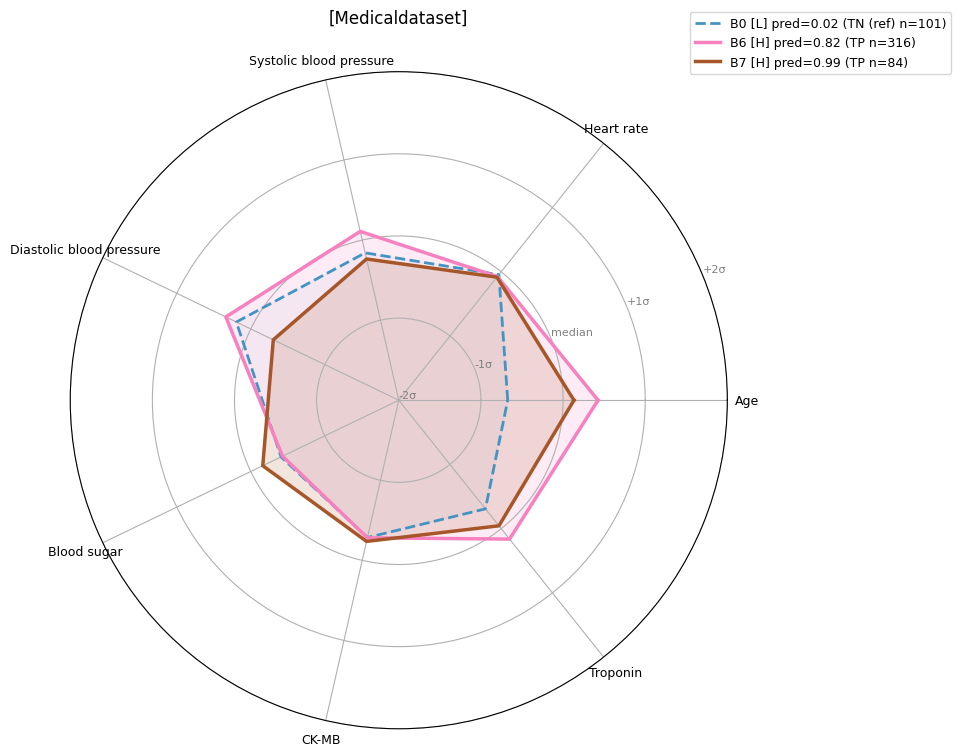

[Cardiovascular_Disease_Dataset] high_risk=[1, 2, 6, 7], active_bases=[1, 6, 7], num_cols=6


/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


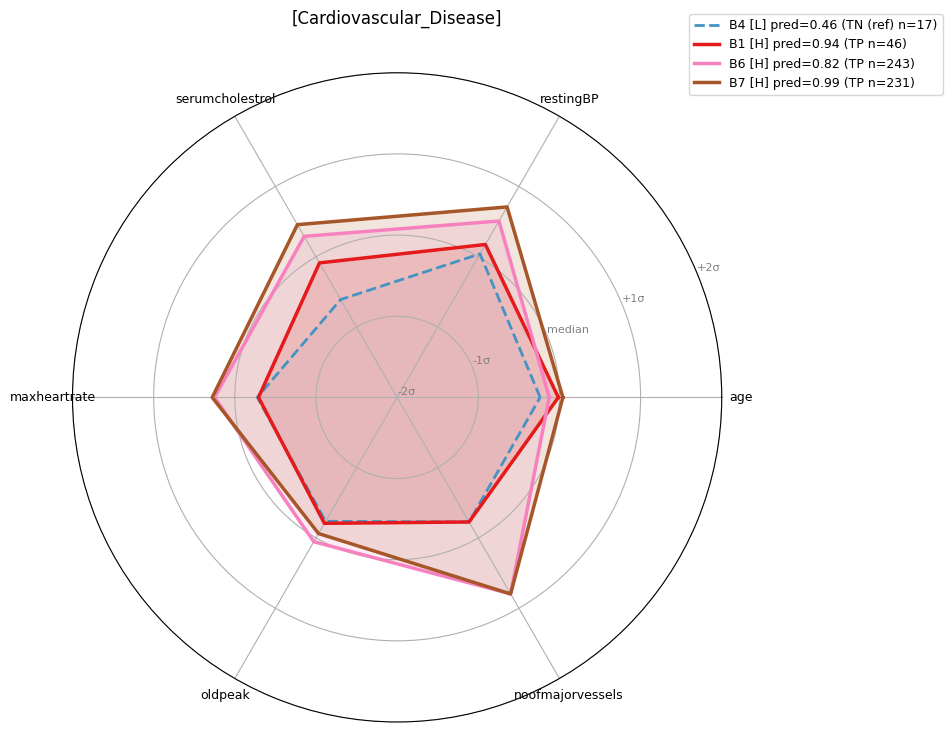

[Heart_disease_statlog] high_risk=[1, 2, 6, 7], active_bases=[1, 6, 7], num_cols=6


/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


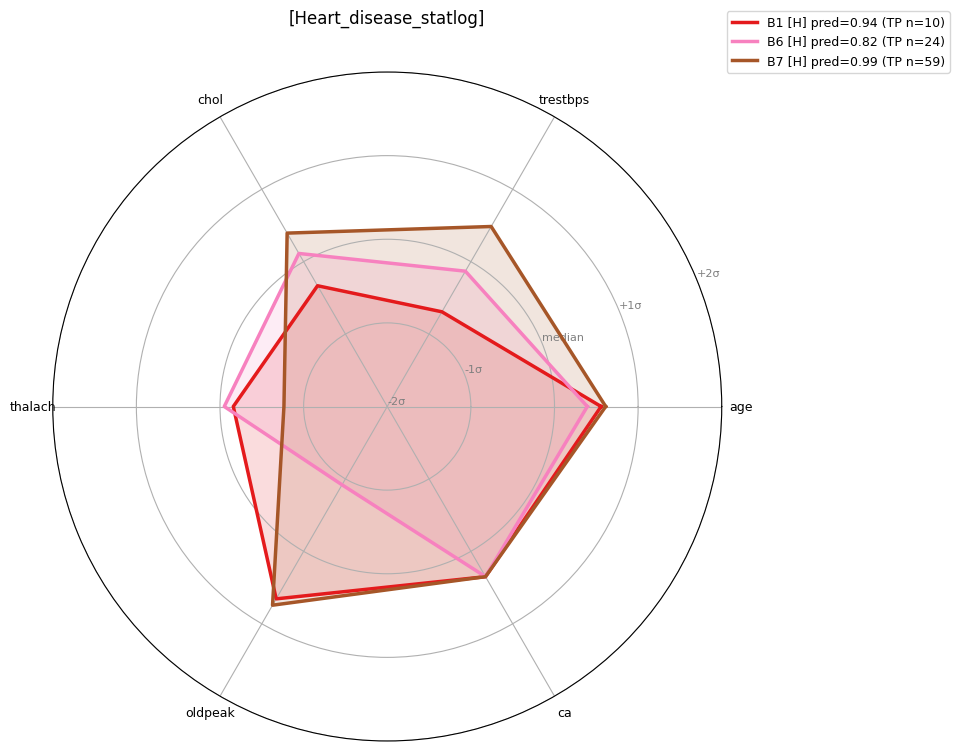

[Erbil_Cardiovascular_Health_Dataset] high_risk=[1, 2, 6, 7], active_bases=[2, 6, 7], num_cols=8


/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


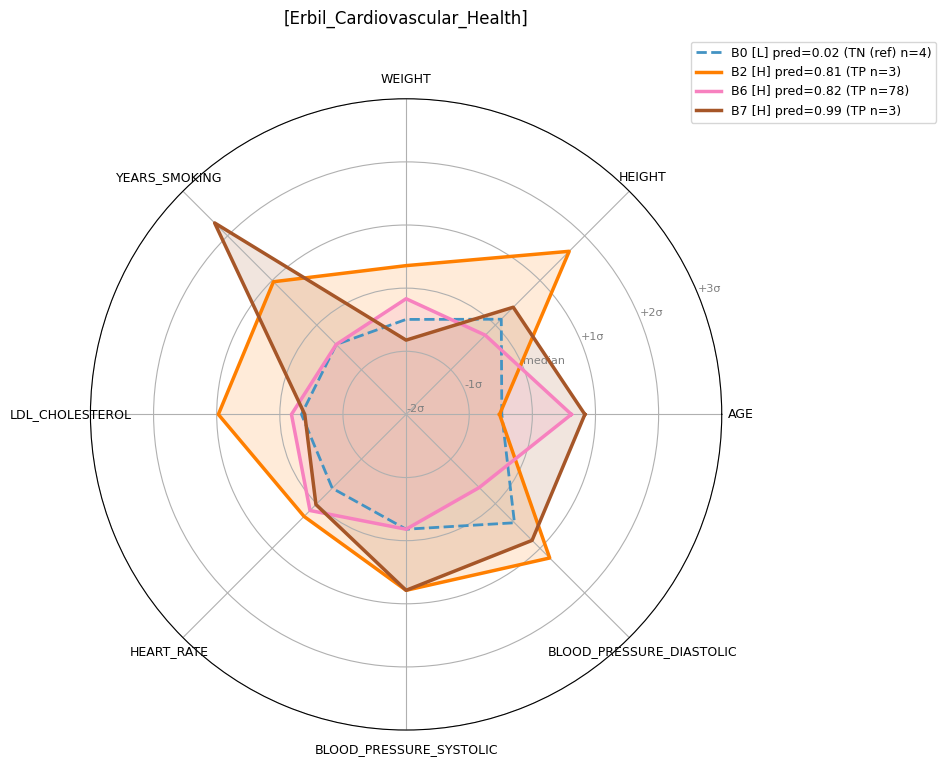

[cardio_SAheart] high_risk=[1, 2, 6, 7], active_bases=[1, 2, 6], num_cols=8


/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


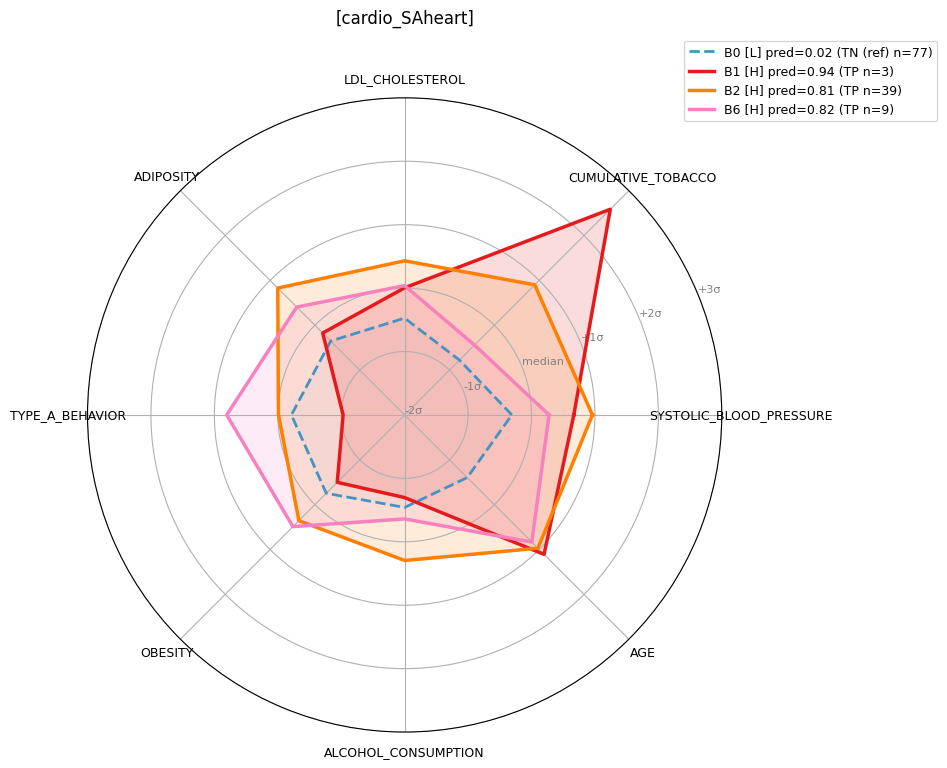

[heart_failure_clinical_records] high_risk=[1, 2, 6, 7], active_bases=[1, 2, 7], num_cols=6


/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


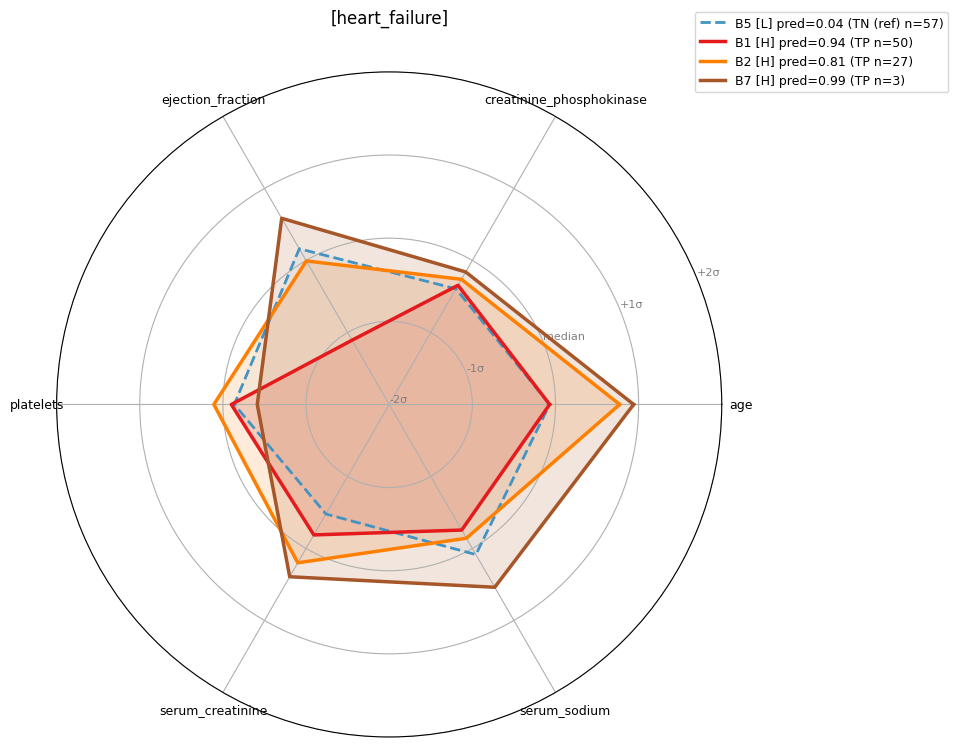

In [72]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

EXCLUDE_FEATURES = {
    'patientid', 'patient_id', 'id', 'ID',
    'time',
}


def plot_radar_basis_comparison(result, onehot_probs, max_features=8, min_tp=3):
    """
    한 source 내에서 고위험 basis들의 TP feature profile을
    radar chart로 겹쳐서 비교
    """
    src_name = result['dataset_name']
    X = result['X']
    argmax = result['argmax']
    tp_mask = result['tp_mask']
    ys = result['ys']
    M = result['pis'].shape[1]

    short_name = src_name.replace('_Dataset', '').replace('_clinical_records', '')

    num_cols = [c for c in X.select_dtypes(include=[np.number]).columns
                if c.lower() not in {f.lower() for f in EXCLUDE_FEATURES}][:max_features]

    if len(num_cols) < 3:
        print(f"[{src_name}] Not enough features for radar chart")
        return

    X_num = X[num_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
    scaler = StandardScaler()
    scaler.fit(X_num)

    high_risk_bases = [k for k in range(M) if onehot_probs[k] > 0.5]
    active_bases = []
    for k in high_risk_bases:
        k_tp = (argmax == k) & tp_mask
        if k_tp.sum() >= min_tp:
            active_bases.append(k)

    print(f"[{src_name}] high_risk={high_risk_bases}, active_bases={active_bases}, num_cols={len(num_cols)}")
    if len(active_bases) < 1:
        print(f"[{src_name}] Not enough active high-risk bases for radar")
        return

    low_risk_bases = [k for k in range(M) if onehot_probs[k] <= 0.5]
    for k in sorted(low_risk_bases, key=lambda k: onehot_probs[k]):
        k_tn = (argmax == k) & (ys == 0)
        if k_tn.sum() >= 3:
            active_bases.insert(0, k)
            break

    n_features = len(num_cols)
    angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False).tolist()
    angles += angles[:1]

    basis_colors = {
        'low': '#4393c3',
        'B0': '#377eb8',
        'B1': '#e41a1c',
        'B2': '#ff7f00',
        'B3': '#4daf4a',
        'B4': '#67a9cf',
        'B5': '#984ea3',
        'B6': '#f781bf',
        'B7': '#a65628',
    }

    fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw=dict(polar=True))

    for k in active_bases:
        is_high = onehot_probs[k] > 0.5

        if is_high:
            k_mask = (argmax == k) & tp_mask
            label_prefix = "TP"
        else:
            k_mask = (argmax == k) & (ys == 0)
            label_prefix = "TN (ref)"

        n = k_mask.sum()
        if n < 1:
            continue

        vals = X_num.loc[k_mask].values
        z_median = np.median(scaler.transform(vals), axis=0).tolist()
        z_median += z_median[:1]

        color = basis_colors.get(f'B{k}', '#999999') if is_high else basis_colors['low']
        risk = "H" if is_high else "L"
        linestyle = '-' if is_high else '--'
        linewidth = 2.5 if is_high else 2.0
        alpha_fill = 0.15 if is_high else 0.05

        ax.plot(angles, z_median, color=color, linewidth=linewidth, linestyle=linestyle,
                label=f'B{k} [{risk}] pred={onehot_probs[k]:.2f} ({label_prefix} n={n})')
        ax.fill(angles, z_median, color=color, alpha=alpha_fill)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(num_cols, fontsize=9)
    # auto ylim from actual plotted values
    all_vals = []
    for line in ax.get_lines():
        all_vals.extend(line.get_ydata())
    if all_vals:
        vmax = max(2, np.ceil(max(all_vals) + 0.3))
        vmin = min(-2, np.floor(min(all_vals) - 0.3))
    else:
        vmax, vmin = 2, -2
    ax.set_ylim(vmin, vmax)
    yticks = [t for t in [-2, -1, 0, 1, 2, 3, 4] if vmin <= t <= vmax]
    ax.set_yticks(yticks)
    ax.set_yticklabels([f'{t:+d}σ' if t != 0 else 'median' for t in yticks], fontsize=8, color='gray')

    ax.legend(fontsize=9, loc='upper right', bbox_to_anchor=(1.35, 1.1))
    ax.set_title(f'[{short_name}]\n',
                 fontsize=12, pad=20)

    plt.tight_layout()
    plt.show()


for src_name in sources:
    plot_radar_basis_comparison(all_results[src_name], onehot_probs)

## Target Adapted Model — Radar

In [73]:
# Load target adapted checkpoint
target_ckpt = torch.load(target_rr_ckpt_path, map_location=device)
target_args = target_ckpt["args"] if isinstance(target_ckpt, dict) and "args" in target_ckpt else args

target_model = Model(
    target_args,
    target_args.input_dim,
    target_args.hidden_dim,
    target_args.output_dim,
    target_args.dropout_rate,
    target_args.llm_model,
    experiment_id="viz",
    mode="Few"
).to(device)

target_sd = target_ckpt["model_state_dict"] if isinstance(target_ckpt, dict) and "model_state_dict" in target_ckpt else target_ckpt
missing, unexpected = target_model.load_state_dict(target_sd, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)
target_model.eval()

Missing keys: []
Unexpected keys: []


Model(
  (latent_graph): LatentCompositeGraph()
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x ModuleList(
        (0-1): 2 x lightGraphNeuralNet(
          (dropout): Dropout(p=0.1, inplace=False)
          (linear): Linear(in_features=768, out_features=192, bias=True)
          (update): Linear(in_features=192, out_features=768, bias=True)
          (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (attn): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): Tanh()
          (2): Linear(in_features=192, out_features=1, bias=True)
        )
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
 

In [74]:
# Target dataloader (전체 데이터)
fix_seed(target_args.random_seed)
targets = target_args.target_data if isinstance(target_args.target_data, (list, tuple)) else [target_args.target_data]

target_loaders = {}
for tgt in targets:
    print(f"Loading dataloader for target: {tgt}")
    res = prepare_embedding_dataloaders(target_args, tgt, is_source=False)
    tr, va, te = res["loaders"]
    from torch.utils.data import ConcatDataset, DataLoader
    datasets = [l.dataset for l in [tr, va, te] if l is not None]
    ds = ConcatDataset(datasets)
    target_loaders[tgt] = DataLoader(ds, batch_size=32, shuffle=False)

>>> [System] Seed 50 FIXED. Deterministic algorithms ENABLED.
Loading dataloader for target: heart
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart.pkl
>>> [DataLoader] Created isolated generator with seed 50
[Target] Train pool size: 734
[Target] Test data size: 184


One-Hot Basis Risk:
  B0: 0.9833 → HIGH
  B1: 0.0609 → LOW
  B2: 0.0026 → LOW
  B3: 0.2534 → LOW
  B4: 0.0036 → LOW
  B5: 0.0197 → LOW
  B6: 0.3051 → LOW
  B7: 0.9156 → HIGH
[heart] N=918, TP=461, TN=200, FP=210, FN=47

[heart] basis distribution:
  B0 [H pred=0.98]: assigned=1, TP=0
  B1 [L pred=0.06]: assigned=244, TP=120
  B2 [L pred=0.00]: assigned=0, TP=0
  B3 [L pred=0.25]: assigned=8, TP=3
  B4 [L pred=0.00]: assigned=14, TP=0
  B5 [L pred=0.02]: assigned=4, TP=3
  B6 [L pred=0.31]: assigned=367, TP=151
  B7 [H pred=0.92]: assigned=280, TP=184
[heart] active_bases=[4, 7, 6, 1]


/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


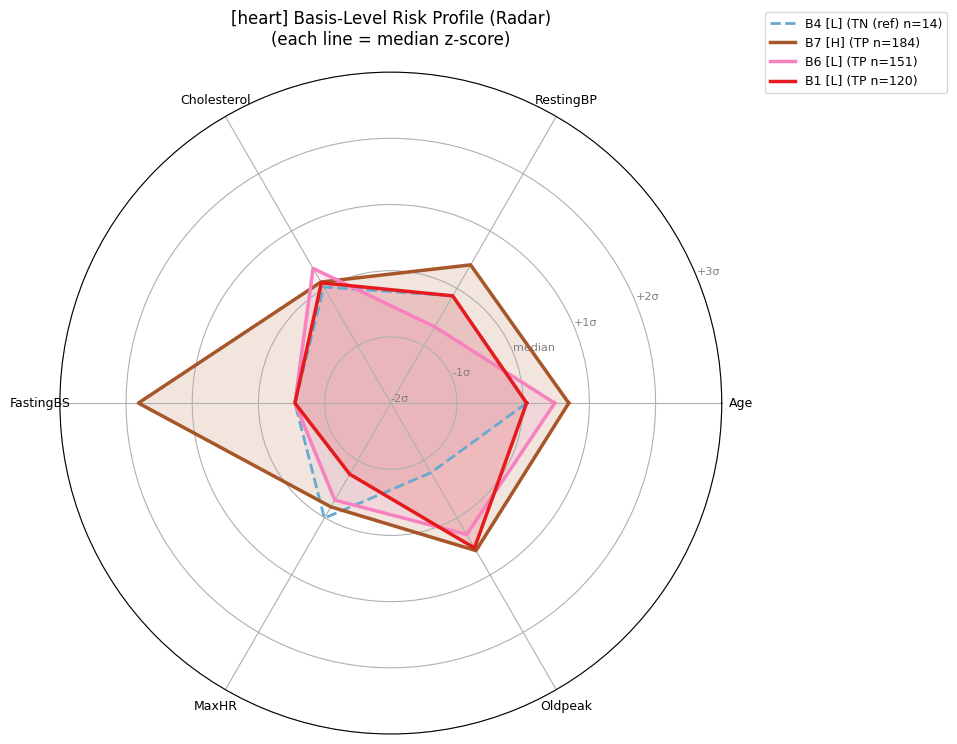

In [81]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Compute onehot risk + extract for target
target_onehot_probs = compute_onehot_basis_risk(target_model, device)

target_results = {}
for tgt in targets:
    target_results[tgt] = extract_tp_tn_with_tabular(target_model, target_loaders[tgt], device, tgt)

# Diagnose: per-basis TP / argmax counts
for tgt in targets:
    r = target_results[tgt]
    print(f"\n[{tgt}] basis distribution:")
    for k in range(r['pis'].shape[1]):
        n_assigned = (r['argmax'] == k).sum()
        n_tp = ((r['argmax'] == k) & r['tp_mask']).sum()
        risk = 'H' if target_onehot_probs[k] > 0.5 else 'L'
        print(f"  B{k} [{risk} pred={target_onehot_probs[k]:.2f}]: assigned={n_assigned}, TP={n_tp}")


# Target 전용 radar (high-risk + TP top-N)
def plot_radar_target(result, onehot_probs, max_features=8, min_tp=1, top_n_tp=3):
    src_name = result['dataset_name']
    X = result['X']
    argmax = result['argmax']
    tp_mask = result['tp_mask']
    ys = result['ys']
    M = result['pis'].shape[1]

    short_name = src_name.replace('_Dataset', '').replace('_clinical_records', '')

    num_cols = [c for c in X.select_dtypes(include=[np.number]).columns
                if c.lower() not in {f.lower() for f in EXCLUDE_FEATURES}][:max_features]
    if len(num_cols) < 3:
        print(f"[{src_name}] Not enough features for radar chart")
        return

    X_num = X[num_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
    scaler = StandardScaler()
    scaler.fit(X_num)

    # high-risk bases with enough TP
    high_risk_bases = [k for k in range(M) if onehot_probs[k] > 0.5]
    active_bases = []
    for k in high_risk_bases:
        if ((argmax == k) & tp_mask).sum() >= min_tp:
            active_bases.append(k)

    # + TP top-N basis (regardless of risk class)
    tp_counts = sorted(
        [(k, int(((argmax == k) & tp_mask).sum())) for k in range(M)],
        key=lambda x: -x[1]
    )
    for k, n in tp_counts[:top_n_tp]:
        if n >= min_tp and k not in active_bases:
            active_bases.append(k)

    # low-risk reference (TN)
    low_risk_bases = [k for k in range(M) if onehot_probs[k] <= 0.5]
    for k in sorted(low_risk_bases, key=lambda k: onehot_probs[k]):
        if ((argmax == k) & (ys == 0)).sum() >= 3 and k not in active_bases:
            active_bases.insert(0, k)
            break

    print(f"[{src_name}] active_bases={active_bases}")
    if len(active_bases) < 1:
        print(f"[{src_name}] No active bases")
        return

    n_features = len(num_cols)
    angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False).tolist()
    angles += angles[:1]

    basis_colors = {
        'low': '#4393c3',
        'B0': '#377eb8', 'B1': '#e41a1c', 'B2': '#ff7f00', 'B3': '#4daf4a',
        'B4': '#67a9cf', 'B5': '#984ea3', 'B6': '#f781bf', 'B7': '#a65628',
    }

    fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw=dict(polar=True))

    for k in active_bases:
        is_high = onehot_probs[k] > 0.5
        if is_high:
            k_mask = (argmax == k) & tp_mask
            label_prefix = "TP"
            linestyle = '-'
        else:
            if ((argmax == k) & tp_mask).sum() >= min_tp:
                k_mask = (argmax == k) & tp_mask
                label_prefix = "TP"
                linestyle = '-'
            else:
                k_mask = (argmax == k) & (ys == 0)
                label_prefix = "TN (ref)"
                linestyle = '--'

        n = k_mask.sum()
        if n < 1:
            continue

        vals = X_num.loc[k_mask].values
        z_median = np.median(scaler.transform(vals), axis=0).tolist()
        z_median += z_median[:1]

        color = basis_colors.get(f'B{k}', '#999999')
        risk = "H" if is_high else "L"
        linewidth = 2.0 if label_prefix == "TN (ref)" else 2.5
        alpha_fill = 0.05 if label_prefix == "TN (ref)" else 0.15

        ax.plot(angles, z_median, color=color, linewidth=linewidth, linestyle=linestyle,
                label=f'B{k} [{risk}] ({label_prefix} n={n})')
        ax.fill(angles, z_median, color=color, alpha=alpha_fill)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(num_cols, fontsize=9)

    all_vals = []
    for line in ax.get_lines():
        all_vals.extend(line.get_ydata())
    if all_vals:
        vmax = max(2, np.ceil(max(all_vals) + 0.3))
        vmin = min(-2, np.floor(min(all_vals) - 0.3))
    else:
        vmax, vmin = 2, -2
    ax.set_ylim(vmin, vmax)
    yticks = [t for t in [-2, -1, 0, 1, 2, 3, 4] if vmin <= t <= vmax]
    ax.set_yticks(yticks)
    ax.set_yticklabels([f'{int(t):+d}σ' if t != 0 else 'median' for t in yticks],
                       fontsize=8, color='gray')

    ax.legend(fontsize=9, loc='upper right', bbox_to_anchor=(1.35, 1.1))
    ax.set_title(f'[{short_name}] Basis-Level Risk Profile (Radar)\n'
                 f'(each line = median z-score)', fontsize=12, pad=20)
    plt.tight_layout()
    plt.show()


for tgt in targets:
    plot_radar_target(target_results[tgt], target_onehot_probs, min_tp=1, top_n_tp=3)
